In [31]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import tifffile

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Устройство: {device}")

✅ Устройство: cuda


In [32]:
# 2. Список файлов для теста
selected_files = [
    "rec_00416.tif", "rec_00461.tif", "rec_00466.tif", "rec_00476.tif",
    "rec_00481.tif", "rec_00621.tif", "rec_00636.tif", "rec_00661.tif",
    "rec_00686.tif", "rec_00756.tif", "rec_00796.tif", "rec_00806.tif",
    "rec_00906.tif", "rec_00956.tif", "rec_00961.tif", "rec_00971.tif",
    "rec_00996.tif", "rec_01026.tif", "rec_01101.tif", "rec_01111.tif",
    "rec_01271.tif", "rec_01471.tif", "rec_01481.tif", "rec_01546.tif",
    "rec_01691.tif", "rec_01796.tif", "rec_01836.tif", "rec_01906.tif",
    "rec_01911.tif", "rec_01941.tif", "rec_02036.tif", "rec_02061.tif",
    "rec_02131.tif", "rec_02186.tif", "rec_02196.tif", "rec_02231.tif",
    "rec_02256.tif", "rec_02286.tif", "rec_02296.tif", "rec_02351.tif",
    "rec_02366.tif", "rec_02411.tif",
]

NOISY_DIR = "filestore/filestorage/V_beton30_angle05"
REF_DIR   = "filestore/filestorage/V_beton30_angle005"
DATA_RANGE = 65535

In [33]:
# 3. Загрузка пар снимков
records = []
for fname in selected_files:
    noisy_path = os.path.join(NOISY_DIR, fname)
    ref_path   = os.path.join(REF_DIR, fname)

    if not (os.path.exists(noisy_path) and os.path.exists(ref_path)):
        print(f"⚠ пропущен, файл не найден: {fname}")
        continue

    noisy = tifffile.imread(noisy_path).astype(np.float32)
    ref   = tifffile.imread(ref_path).astype(np.float32)
    records.append({"name": fname, "noisy": noisy, "ref": ref})

print(f"Загружено {len(records)} из {len(selected_files)} файлов")

Загружено 42 из 42 файлов


In [34]:
# 4. Функции нарезки и сборки патчей
def slice_image_to_patches(image_or_path, patch_size=256, overlap_ratio=0.2):
    if isinstance(image_or_path, str):
        img = tifffile.imread(image_or_path).astype(np.float32)
    else:
        img = image_or_path.astype(np.float32)

    h, w = img.shape
    stride = int(patch_size * (1.0 - overlap_ratio))

    y_steps = list(range(0, h - patch_size + 1, stride))
    if y_steps[-1] != h - patch_size: y_steps.append(h - patch_size)

    x_steps = list(range(0, w - patch_size + 1, stride))
    if x_steps[-1] != w - patch_size: x_steps.append(w - patch_size)

    patches, coords = [], []
    for y in y_steps:
        for x in x_steps:
            patches.append(img[y:y+patch_size, x:x+patch_size])
            coords.append((y, x))

    return np.array(patches), coords, (h, w)


def stitch_patches(pred_patches, coords, orig_shape, patch_size):
    h, w = orig_shape
    canvas = np.zeros((h, w), dtype=np.float32)
    weight = np.zeros((h, w), dtype=np.float32)

    win_1d = np.hanning(patch_size)
    win_1d = np.clip(win_1d, 1e-3, None)
    win_2d = np.outer(win_1d, win_1d)

    for patch, (y, x) in zip(pred_patches, coords):
        canvas[y:y+patch_size, x:x+patch_size] += patch * win_2d
        weight[y:y+patch_size, x:x+patch_size] += win_2d

    weight[weight == 0] = 1.0
    return canvas / weight


def compute_metrics(pred, ref, data_range):
    return {
        "psnr": psnr(ref, pred, data_range=data_range),
        "ssim": ssim(ref, pred, data_range=data_range),
    }

In [35]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import pandas as pd

In [36]:
results_unet = []
for rec in records:
    denoised = run_unet_on_full_image(model_unet, rec["noisy"], device,
                                       patch_size=128, overlap_ratio=0.2)
    m = compute_metrics(denoised, rec["ref"], DATA_RANGE)
    m_noisy = compute_metrics(rec["noisy"], rec["ref"], DATA_RANGE)  # baseline до денойзинга
    results_unet.append({
        "name": rec["name"],
        "psnr_denoised": m["psnr"], "ssim_denoised": m["ssim"],
        "psnr_noisy": m_noisy["psnr"], "ssim_noisy": m_noisy["ssim"],
    })
    rec["denoised_unet"] = denoised  # отдельный ключ, чтобы не перезаписать denoised от Restormer

df_unet = pd.DataFrame(results_unet)
print(df_unet)
print("\nСредние значения (U-Net):")
print(df_unet[["psnr_denoised", "ssim_denoised", "psnr_noisy", "ssim_noisy"]].describe())

df_unet.to_csv("metrics_results_unet.csv", index=False)

             name  psnr_denoised  ssim_denoised  psnr_noisy  ssim_noisy
0   rec_00416.tif       7.738798       0.247678   20.397908    0.439962
1   rec_00461.tif       7.794051       0.247874   20.462164    0.441390
2   rec_00466.tif       7.795832       0.247395   20.466671    0.440266
3   rec_00476.tif       7.815449       0.247511   20.484639    0.440266
4   rec_00481.tif       7.828879       0.247173   20.488544    0.439995
5   rec_00621.tif       8.003028       0.247953   20.660655    0.443705
6   rec_00636.tif       8.041057       0.247770   20.680179    0.443356
7   rec_00661.tif       8.051247       0.247798   20.712017    0.444369
8   rec_00686.tif       8.105379       0.248438   20.760665    0.446909
9   rec_00756.tif       8.155618       0.249512   20.805895    0.449122
10  rec_00796.tif       8.186484       0.249554   20.791946    0.449151
11  rec_00806.tif       8.172613       0.250033   20.791211    0.450446
12  rec_00906.tif       8.179944       0.248869   20.730918    0

In [37]:
def measure_inference_time_unet(model, image, device, n_warmup=2, n_runs=5,
                                 patch_size=128, overlap_ratio=0.2):
    for _ in range(n_warmup):
        _ = run_unet_on_full_image(model, image, device, patch_size, overlap_ratio)
    if device.type == "cuda":
        torch.cuda.synchronize()

    times = []
    for _ in range(n_runs):
        if device.type == "cuda":
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        _ = run_unet_on_full_image(model, image, device, patch_size, overlap_ratio)
        if device.type == "cuda":
            torch.cuda.synchronize()
        times.append(time.perf_counter() - t0)
    return np.mean(times), np.std(times)

import time
sample_image = records[0]["noisy"]
mean_t_unet, std_t_unet = measure_inference_time_unet(model_unet, sample_image, device,
                                                        patch_size=128, overlap_ratio=0.2)
print(f"Время инференса U-Net на снимок ({records[0]['name']}, {sample_image.shape}): "
      f"{mean_t_unet:.3f} ± {std_t_unet:.3f} с")

Время инференса U-Net на снимок (rec_00416.tif, (3067, 3067)): 0.967 ± 0.007 с


             name  psnr_denoised  ssim_denoised  psnr_noisy  ssim_noisy
0   rec_00416.tif       7.738798       0.247678   20.397908    0.439962
1   rec_00461.tif       7.794051       0.247874   20.462164    0.441390
2   rec_00466.tif       7.795832       0.247395   20.466671    0.440266
3   rec_00476.tif       7.815449       0.247511   20.484639    0.440266
4   rec_00481.tif       7.828879       0.247173   20.488544    0.439995
5   rec_00621.tif       8.003028       0.247953   20.660655    0.443705
6   rec_00636.tif       8.041057       0.247770   20.680179    0.443356
7   rec_00661.tif       8.051247       0.247798   20.712017    0.444369
8   rec_00686.tif       8.105379       0.248438   20.760665    0.446909
9   rec_00756.tif       8.155618       0.249512   20.805895    0.449122
10  rec_00796.tif       8.186484       0.249554   20.791946    0.449151
11  rec_00806.tif       8.172613       0.250033   20.791211    0.450446
12  rec_00906.tif       8.179944       0.248869   20.730918    0

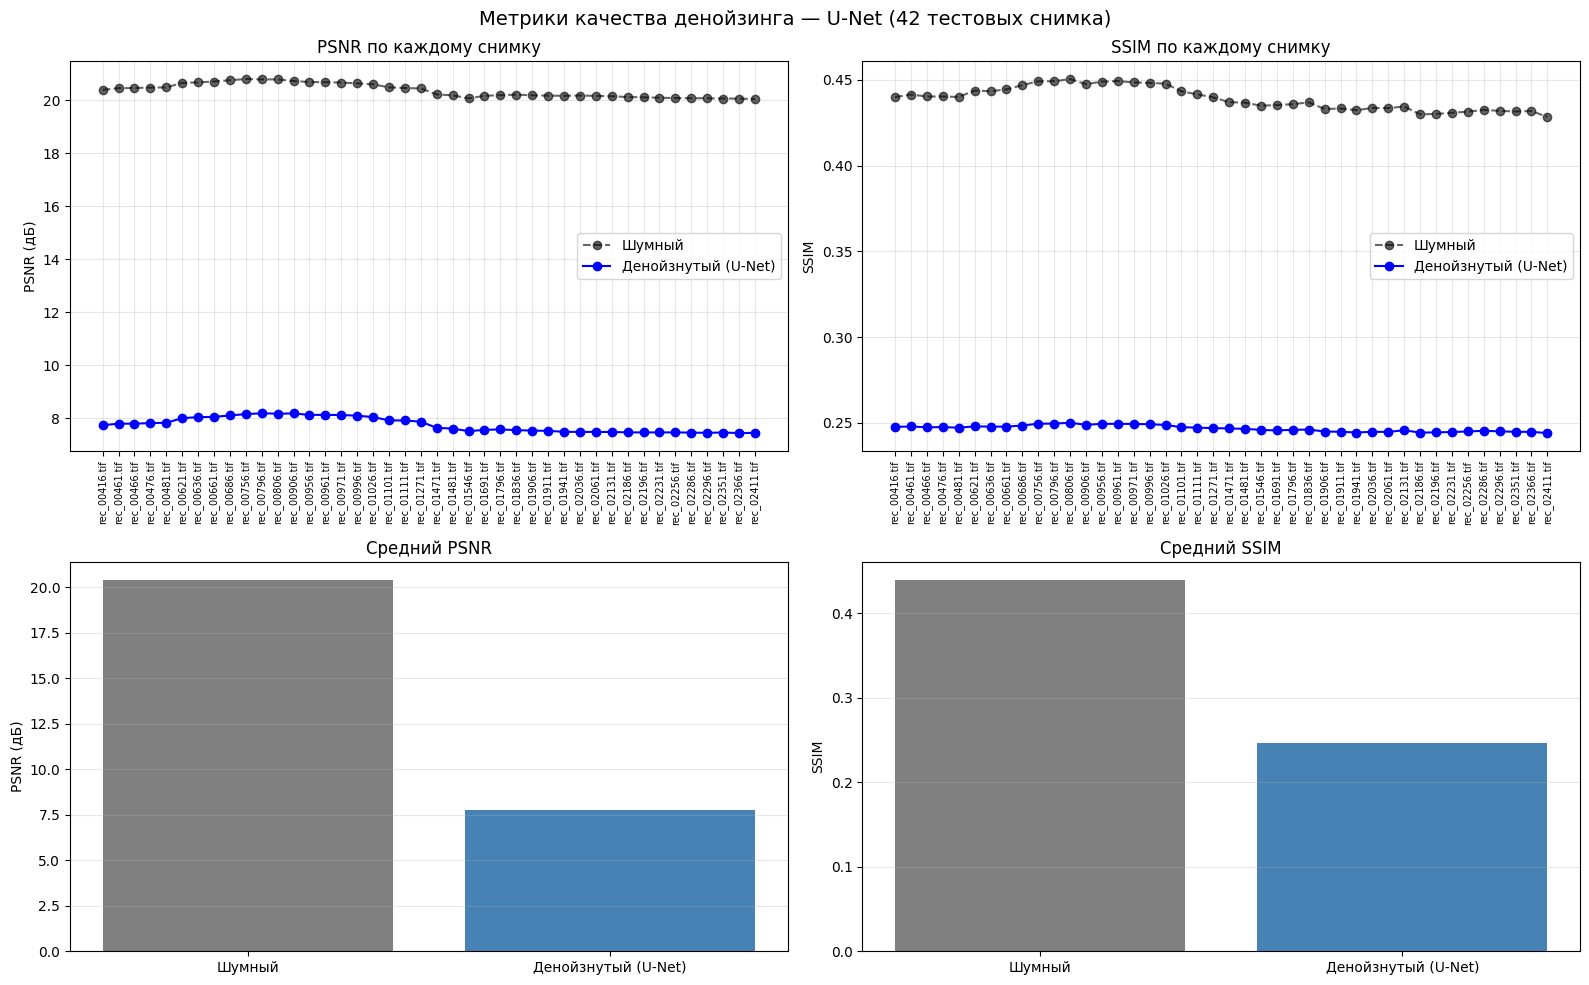

In [ ]:
results_unet = []
for rec in records:
    denoised = run_unet_on_full_image(model_unet, rec["noisy"], device,
                                       patch_size=128, overlap_ratio=0.2)
    m = compute_metrics(denoised, rec["ref"], DATA_RANGE)
    m_noisy = compute_metrics(rec["noisy"], rec["ref"], DATA_RANGE)  # baseline до денойзинга
    results_unet.append({
        "name": rec["name"],
        "psnr_denoised": m["psnr"], "ssim_denoised": m["ssim"],
        "psnr_noisy": m_noisy["psnr"], "ssim_noisy": m_noisy["ssim"],
    })
    rec["denoised_unet"] = denoised  # отдельный ключ, чтобы не перезаписать denoised от Restormer

df_unet = pd.DataFrame(results_unet)
print(df_unet)
print("\nСредние значения (U-Net):")
print(df_unet[["psnr_denoised", "ssim_denoised", "psnr_noisy", "ssim_noisy"]].describe())

df_unet.to_csv("metrics_results_unet.csv", index=False)

# ==============================================================================
# ГРАФИК: PSNR и SSIM по каждому снимку (U-Net) — denoised vs noisy
# ==============================================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

x = range(len(df_unet))

# --- PSNR по снимкам ---
axes[0, 0].plot(x, df_unet["psnr_noisy"], "ko--", label="Шумный", alpha=0.6)
axes[0, 0].plot(x, df_unet["psnr_denoised"], "bo-", label="Денойзнутый (U-Net)")
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(df_unet["name"], rotation=90, fontsize=7)
axes[0, 0].set_ylabel("PSNR (дБ)")
axes[0, 0].set_title("PSNR по каждому снимку")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# --- SSIM по снимкам ---
axes[0, 1].plot(x, df_unet["ssim_noisy"], "ko--", label="Шумный", alpha=0.6)
axes[0, 1].plot(x, df_unet["ssim_denoised"], "bo-", label="Денойзнутый (U-Net)")
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(df_unet["name"], rotation=90, fontsize=7)
axes[0, 1].set_ylabel("SSIM")
axes[0, 1].set_title("SSIM по каждому снимку")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# --- Сводный бар-график: средние значения ---
metrics_summary = pd.DataFrame({
    "condition": ["Шумный", "Денойзнутый (U-Net)"],
    "psnr_mean": [df_unet["psnr_noisy"].mean(), df_unet["psnr_denoised"].mean()],
    "ssim_mean": [df_unet["ssim_noisy"].mean(), df_unet["ssim_denoised"].mean()],
})

axes[1, 0].bar(metrics_summary["condition"], metrics_summary["psnr_mean"],
               color=["gray", "steelblue"])
axes[1, 0].set_ylabel("PSNR (дБ)")
axes[1, 0].set_title("Средний PSNR")
axes[1, 0].grid(True, axis="y", alpha=0.3)

axes[1, 1].bar(metrics_summary["condition"], metrics_summary["ssim_mean"],
               color=["gray", "steelblue"])
axes[1, 1].set_ylabel("SSIM")
axes[1, 1].set_title("Средний SSIM")
axes[1, 1].grid(True, axis="y", alpha=0.3)

plt.suptitle("Метрики качества денойзинга — U-Net (42 тестовых снимка)", fontsize=14)
plt.tight_layout()
plt.savefig("unet_metrics_summary.png", dpi=150, bbox_inches="tight")
plt.show()

In [40]:
print(records[0].keys())

dict_keys(['name', 'noisy', 'ref', 'denoised_unet'])


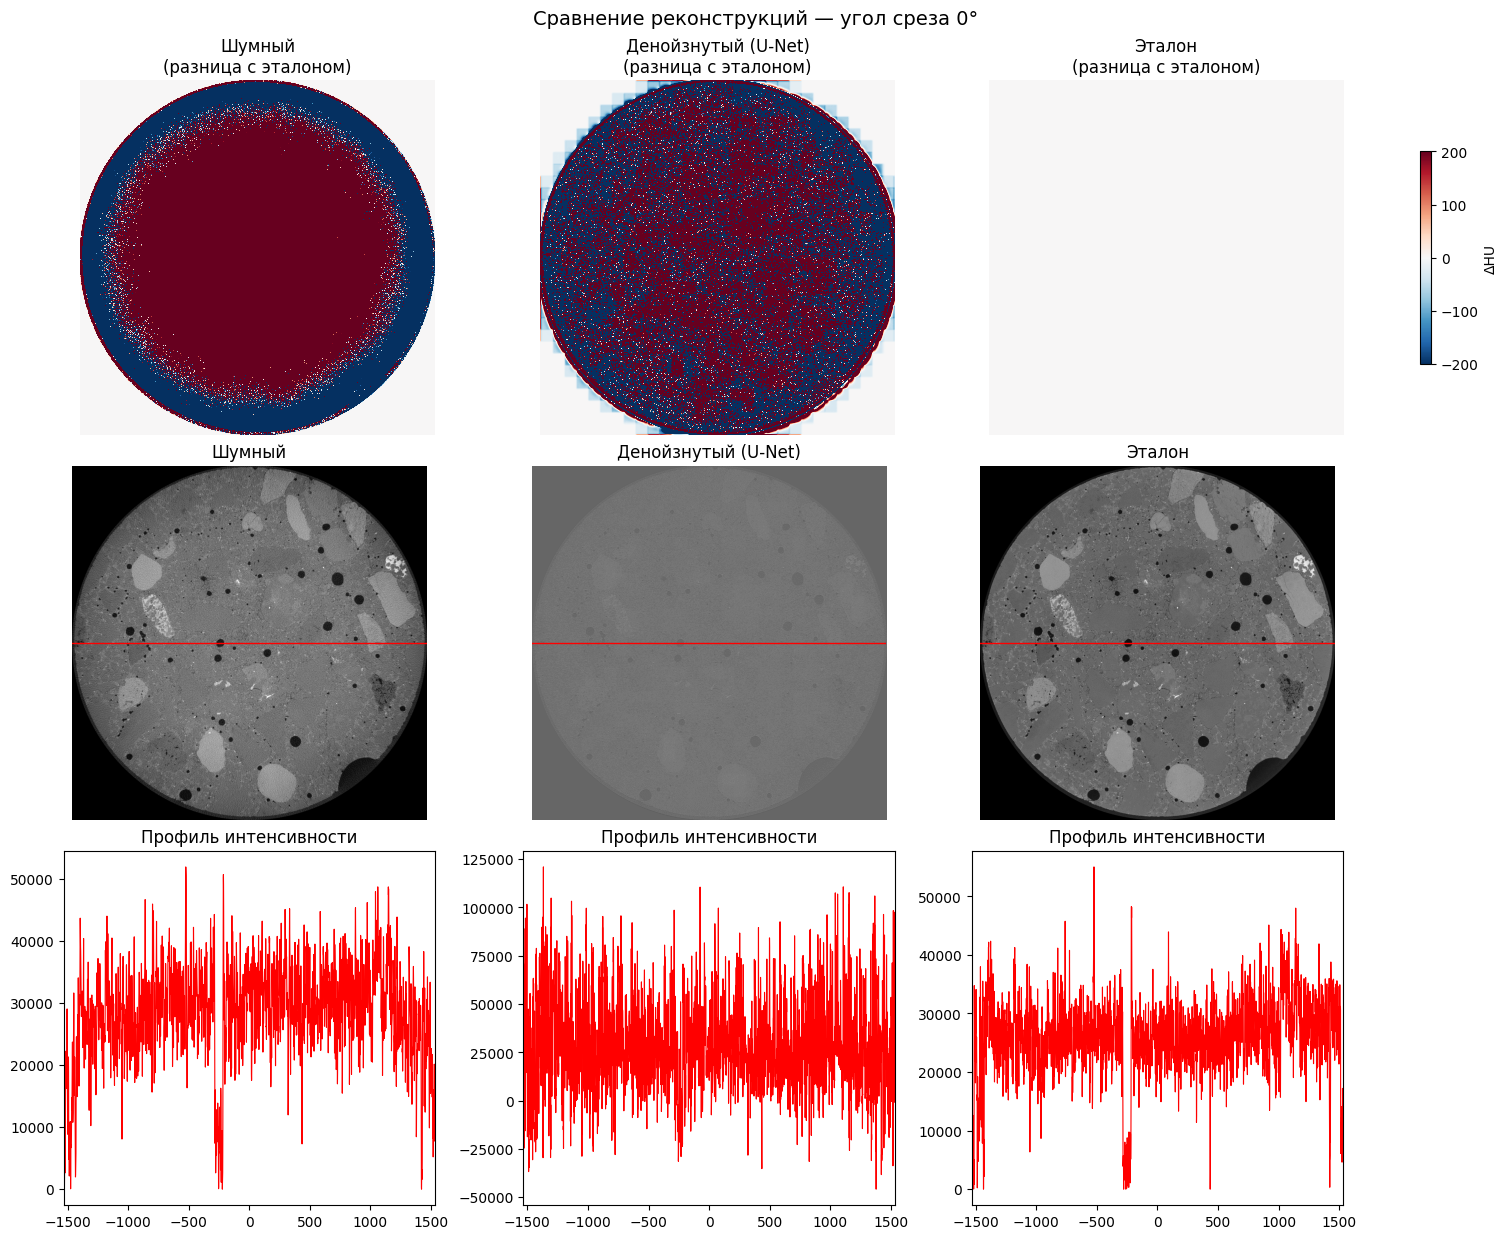

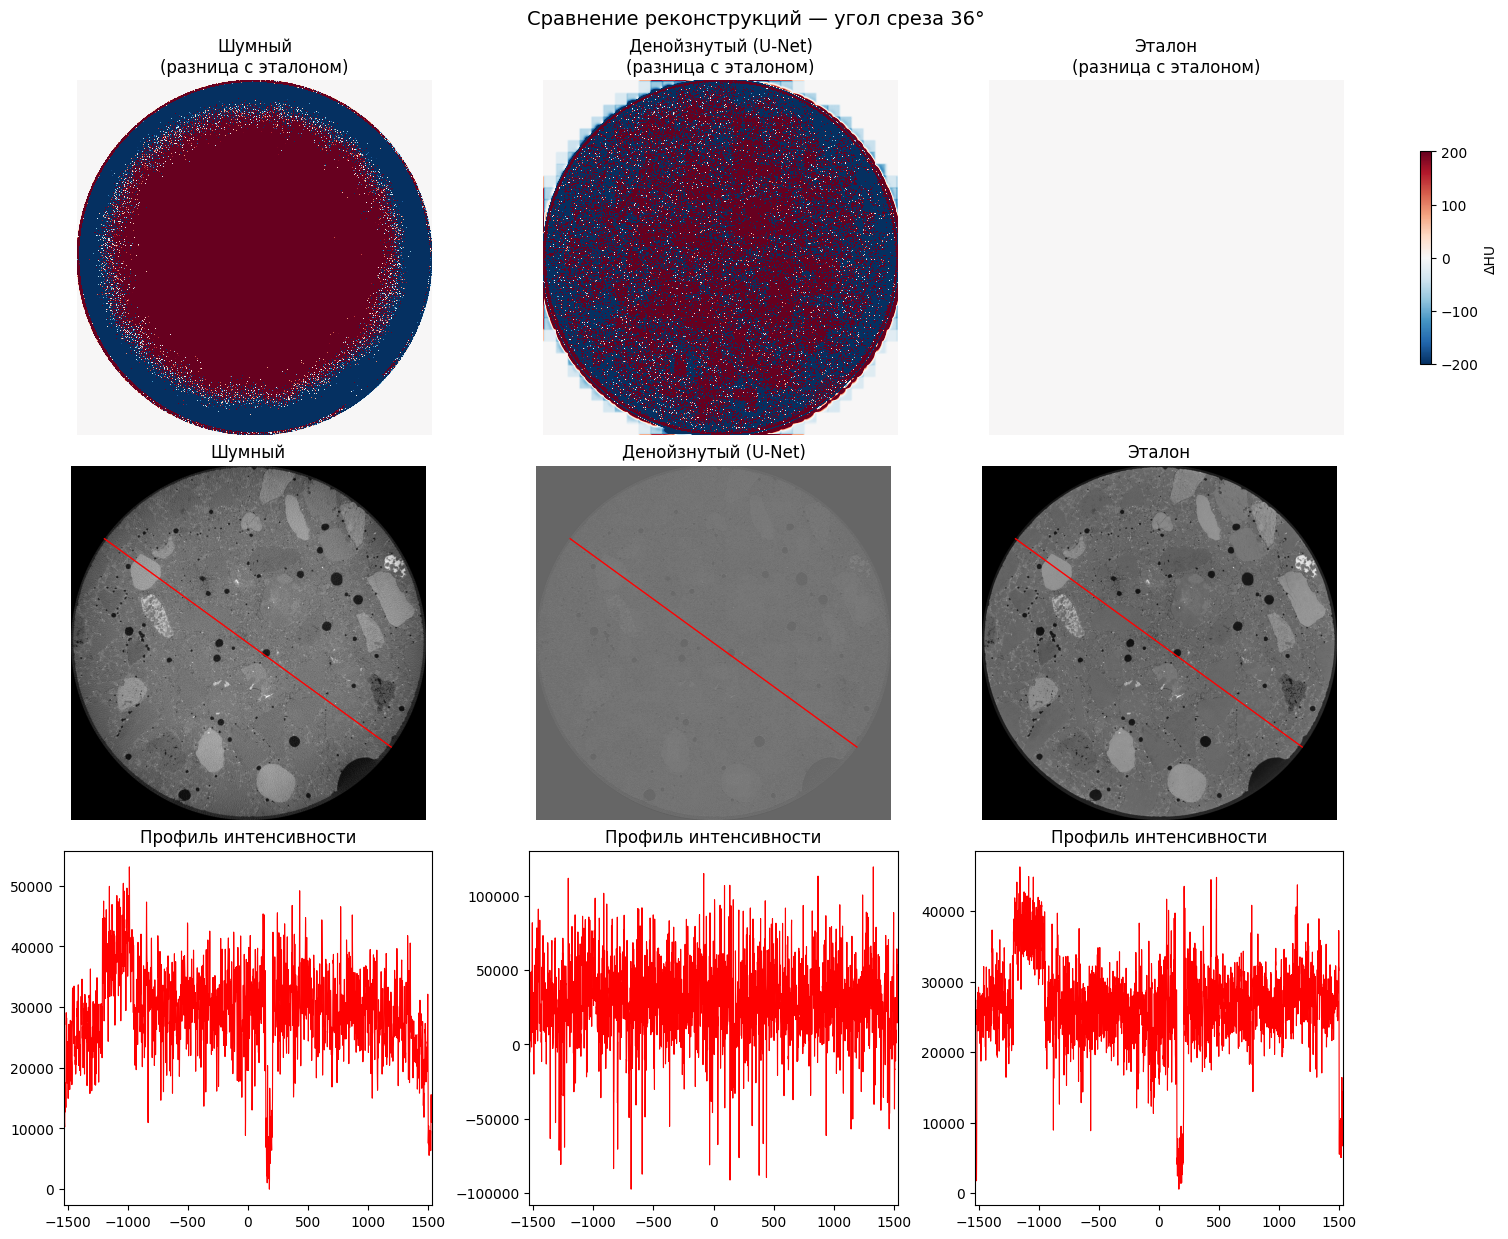

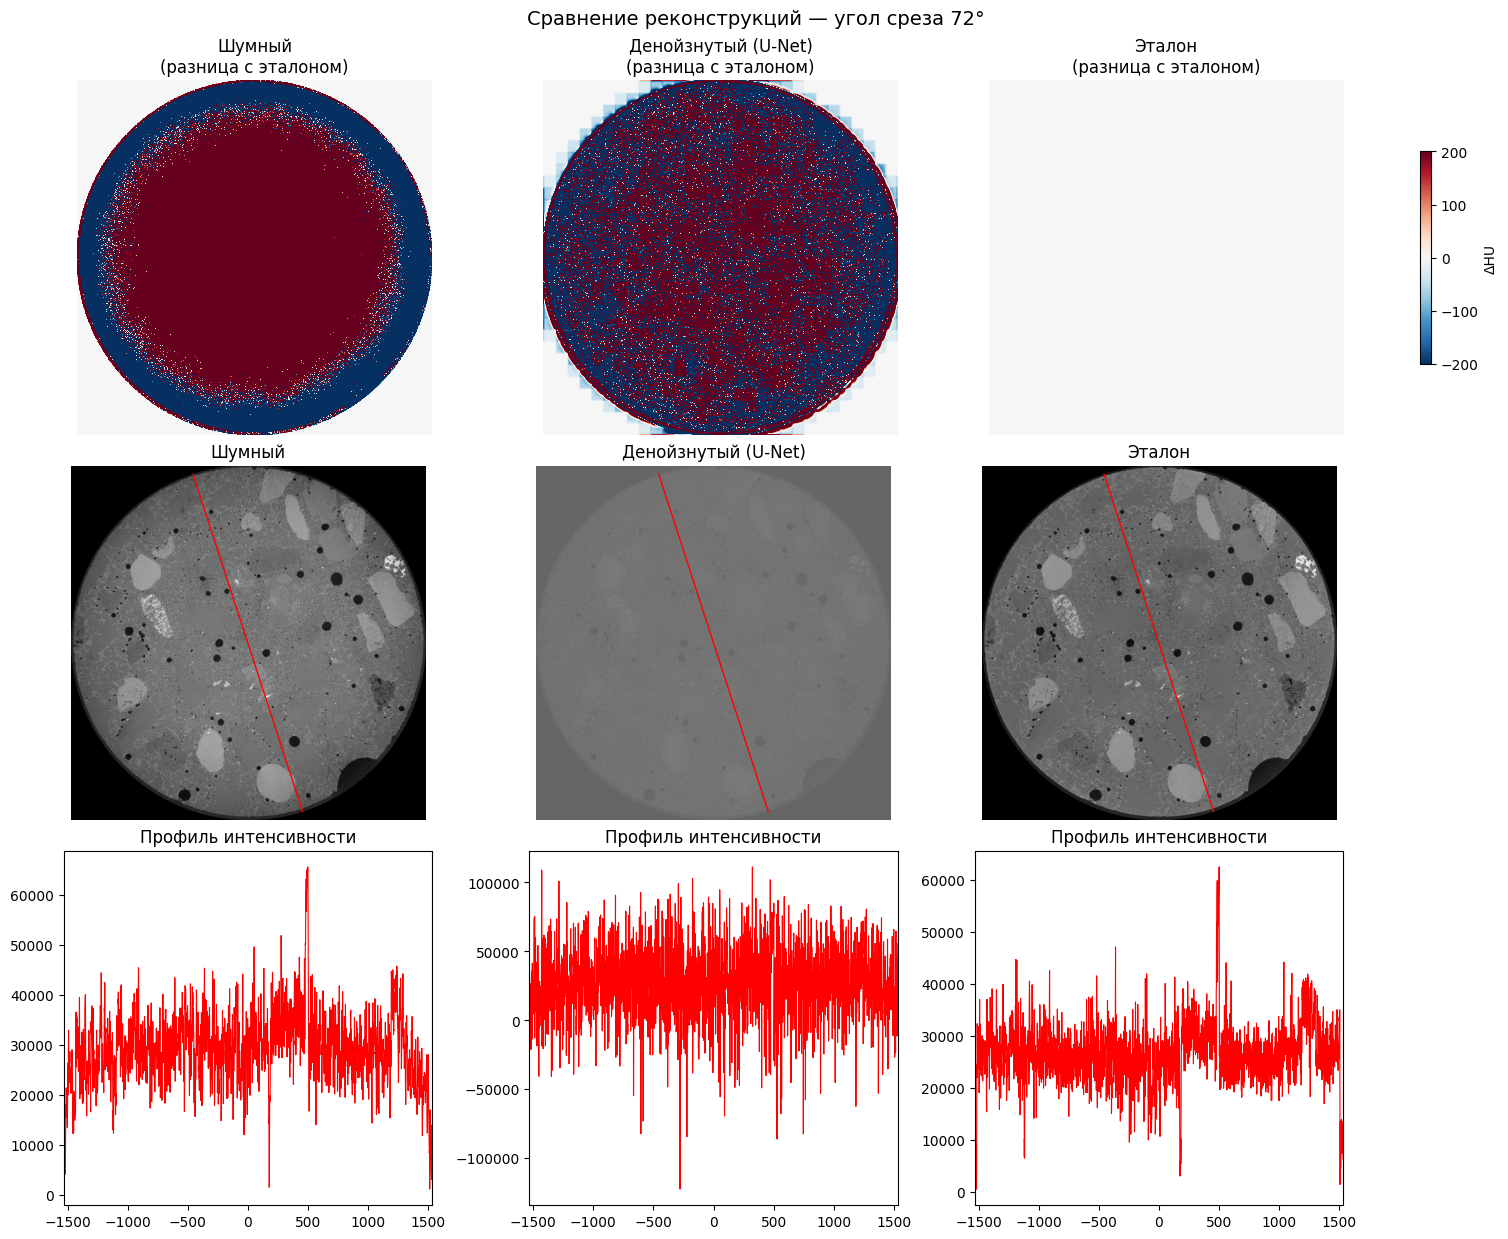

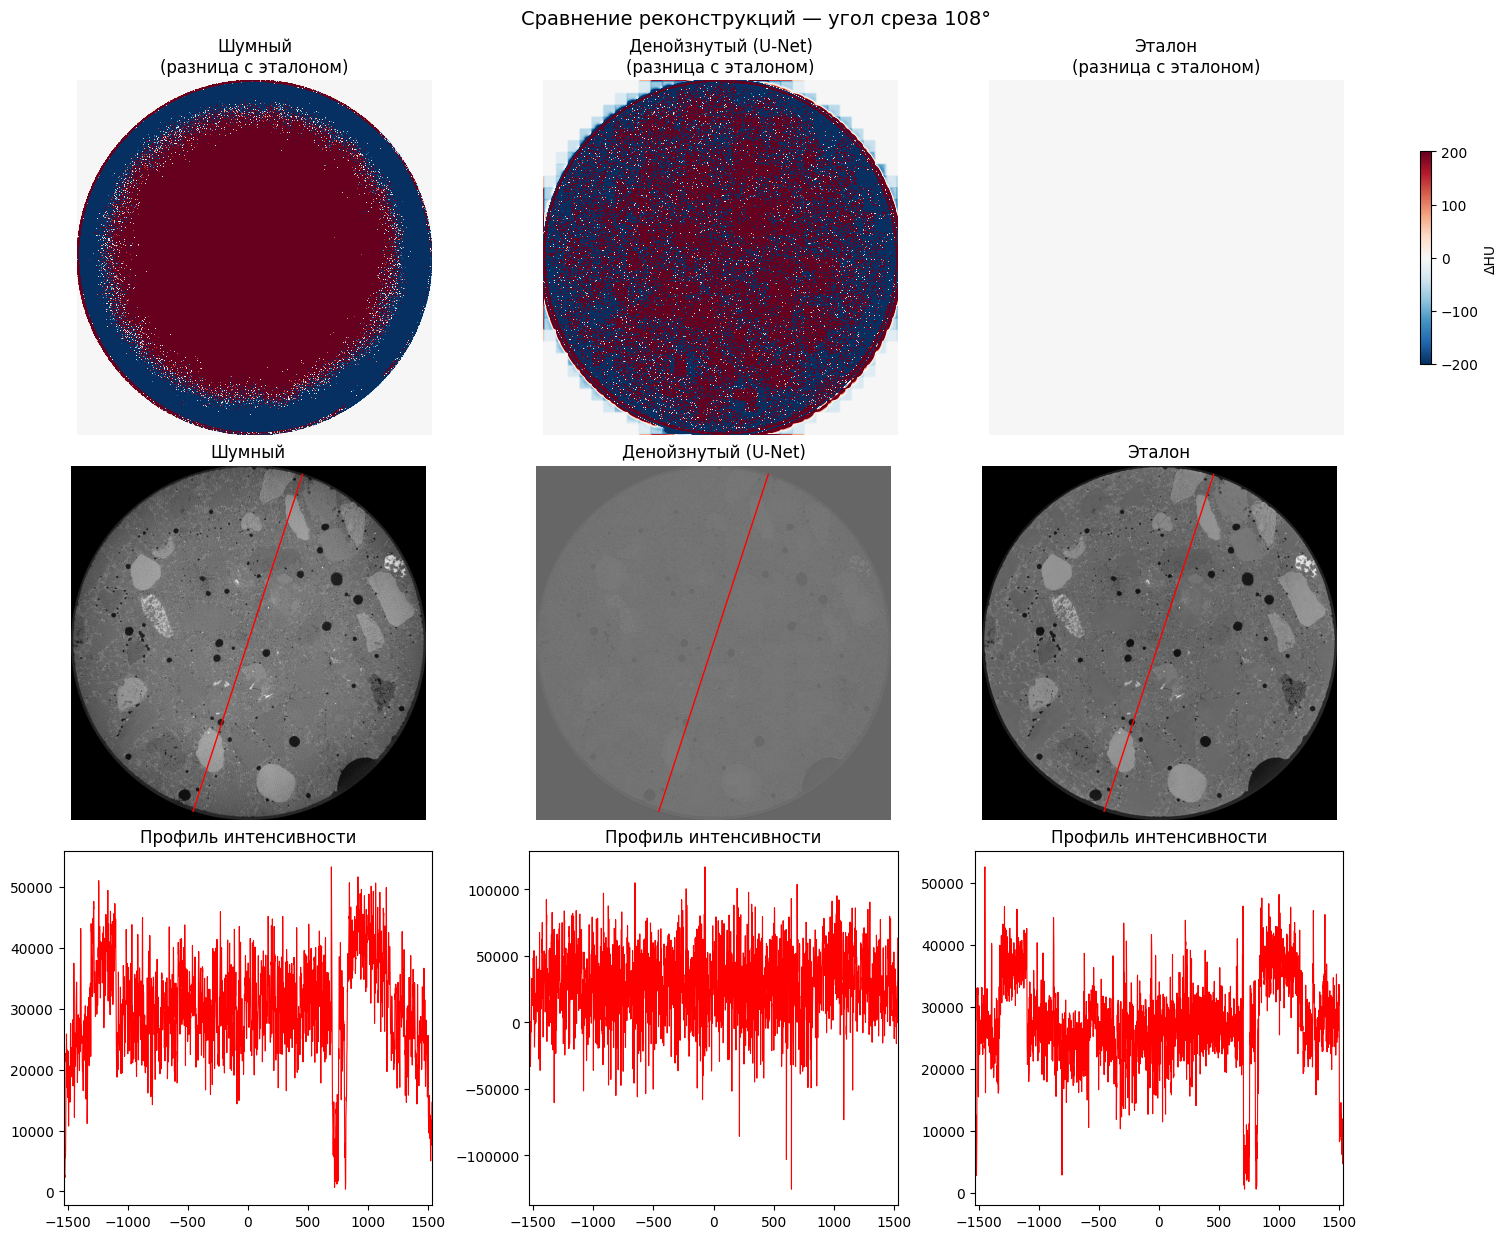

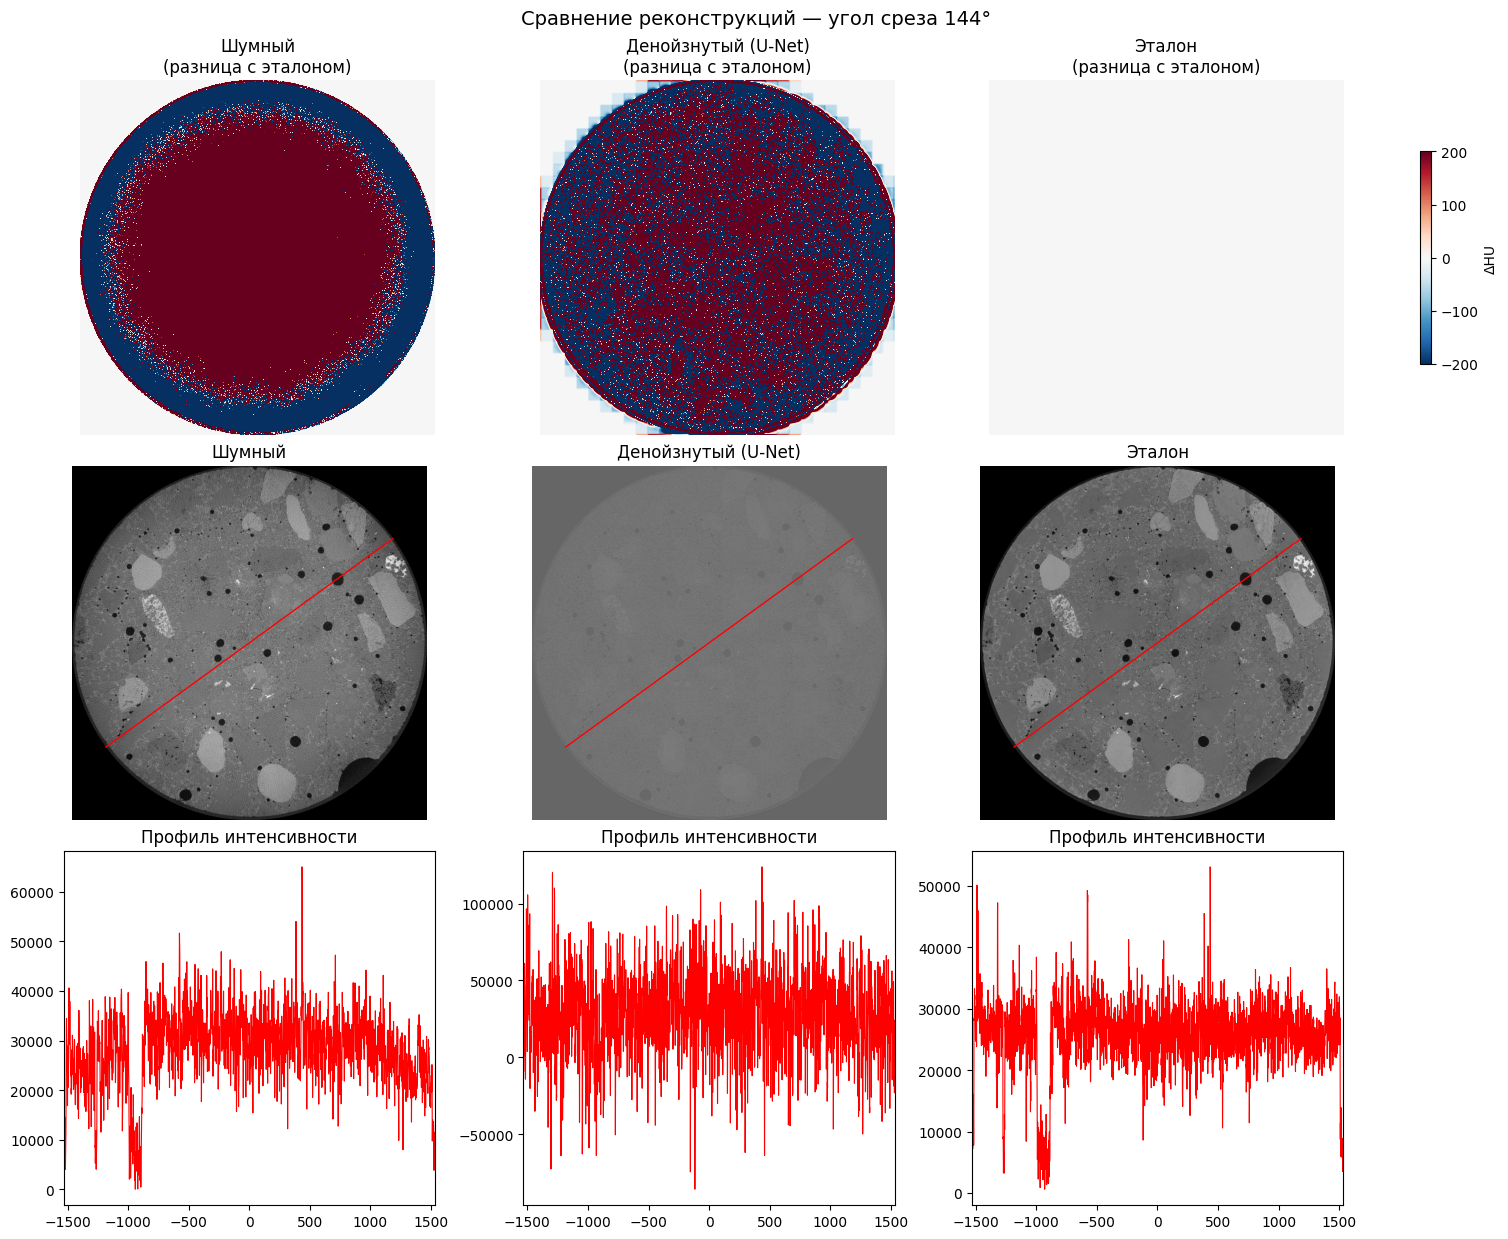

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import map_coordinates

def get_diameter_line(image, center, radius, angle_deg):
    angle_rad = np.deg2rad(angle_deg)
    dx, dy = np.cos(angle_rad), np.sin(angle_rad)
    t = np.linspace(-radius, radius, int(2 * radius))
    x = center[1] + t * dx
    y = center[0] + t * dy
    coords = np.vstack([y, x])
    values = map_coordinates(image, coords, order=1, mode='nearest')
    return t, values


def plot_paper_style_grid(angle_deg, save_name=None):
    example = records[0]
    h, w = example["noisy"].shape
    center = (h // 2, w // 2)
    radius = min(h, w) // 2

    images = {
        "Шумный": example["noisy"],
        "Денойзнутый (U-Net)": example["denoised_unet"],
        "Эталон": example["ref"],
    }

    angle_rad = np.deg2rad(angle_deg)
    x0 = center[1] - radius * np.cos(angle_rad)
    y0 = center[0] - radius * np.sin(angle_rad)
    x1 = center[1] + radius * np.cos(angle_rad)
    y1 = center[0] + radius * np.sin(angle_rad)

    n_cols = len(images)
    fig, axes = plt.subplots(3, n_cols, figsize=(5 * n_cols, 12), constrained_layout=True)

    vmin_diff, vmax_diff = -200, 200

    im = None
    for col_idx, (label, img) in enumerate(images.items()):
        diff = img - example["ref"]

        im = axes[0, col_idx].imshow(diff, cmap="RdBu_r", vmin=vmin_diff, vmax=vmax_diff)
        axes[0, col_idx].set_title(f"{label}\n(разница с эталоном)")
        axes[0, col_idx].axis("off")

        axes[1, col_idx].imshow(img, cmap="gray")
        axes[1, col_idx].plot([x0, x1], [y0, y1], color="red", linewidth=1)
        axes[1, col_idx].set_title(label)
        axes[1, col_idx].axis("off")

        t, vals = get_diameter_line(img, center, radius, angle_deg)
        axes[2, col_idx].plot(t, vals, color="red", linewidth=0.8)
        axes[2, col_idx].set_title("Профиль интенсивности")
        axes[2, col_idx].set_xlim(t.min(), t.max())

    fig.colorbar(im, ax=axes[0, :].tolist(), shrink=0.6, label="ΔHU")
    plt.suptitle(f"Сравнение реконструкций — угол среза {angle_deg:.0f}°", fontsize=14, y=1.02)

    if save_name:
        plt.savefig(save_name, dpi=150, bbox_inches="tight")
    plt.show()


# ==============================================================================
# Выводим 5 фото с разных ракурсов (углов)
# ==============================================================================
angles = [0, 36, 72, 108, 144]  # 5 углов, равномерно от 0 до 180

for angle in angles:
    plot_paper_style_grid(angle, save_name=f"profile_angle_{angle:.0f}.png")

In [39]:
comparison = pd.DataFrame({
    "model": ["Restormer", "U-Net"],
    "psnr_mean": [df["psnr_denoised"].mean(), df_unet["psnr_denoised"].mean()],
    "ssim_mean": [df["ssim_denoised"].mean(), df_unet["ssim_denoised"].mean()],
    "inference_time_sec": [mean_t, mean_t_unet],  # mean_t — из вашего замера Restormer
})
print(comparison)
comparison.to_csv("model_comparison.csv", index=False)

NameError: name 'df' is not defined